# Imports

In [22]:
import os
import json
import requests
import asyncio
import threading
import queue
import uuid
import uvicorn
import pandas as pd
from typing import List, TypedDict, Optional
from dotenv import load_dotenv
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.tools import tool
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langchain_core.runnables.graph import MermaidDrawMethod
from langchain_core.runnables.config import RunnableConfig
from langchain_core.messages import ToolMessage
from pydantic import BaseModel
from fastapi import FastAPI, Response, BackgroundTasks, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


_ = load_dotenv() 

In [23]:
import logging
import warnings

# ignore noisy warnings
logging.disable(logging.CRITICAL)
warnings.filterwarnings("ignore")

# Prompts

In [24]:
CON_PROMPT = """You are the CON agent in a formal debate. Your role is to argue AGAINST the following proposition:

"{proposition}"

DEBATE RULES:
1. You will participate in 3 rounds of debate
2. Present your strongest arguments against the proposition
3. Use evidence, logic, and reasoning to support your position
4. You have access to a web_search tool when you need to find supporting information
5. Be respectful but persuasive
6. Focus on the substance of the argument, not rhetoric
7. Respond directly to your opponent's points in rounds 2 and 3
8. Be concise and to the point
9. Limit your response to around 100 words maximum.

TOOLS:
- web_search: Use this to search for evidence that supports your position

IMPORTANT: You are the CON agent arguing AGAINST the proposition.

{chat_history}

— CON
"""

PRO_PROMPT = """You are the PRO agent in a formal debate. Your role is to argue FOR the following proposition:

"{proposition}"

DEBATE RULES:
1. You will participate in 3 rounds of debate
2. Present your strongest arguments in favor of the proposition
3. Use evidence, logic, and reasoning to support your position
4. You have access to a web_search tool when you need to find supporting information
5. Be respectful but persuasive
6. Focus on the substance of the argument, not rhetoric
7. Respond directly to your opponent's points in rounds 2 and 3
8. Be concise and to the point
9. Limit your response to around 100 words maximum.

TOOLS:
- web_search: Use this to search for evidence that supports your position

IMPORTANT: You are the PRO agent arguing FOR the proposition.

{chat_history}

— PRO
"""

JUDGE_PROMPT = """You are the JUDGE in a formal debate on the proposition:

"{proposition}"

Your role is to evaluate the arguments presented by the PRO and CON agents impartially.

JUDGE RESPONSIBILITIES:
1. Assess the strength of arguments from both sides
2. Evaluate the quality of evidence and reasoning
3. Consider the effectiveness of rebuttals
4. Identify logical fallacies or weak arguments
5. After each round, provide a brief score-card (maximum 30 words)
6. After the third round, declare a winner based on overall performance
7. At the end of the debate, and once you make the final decision o the winner, request a call to `record_win`
tool and give the winner a point

DEBATE FORMAT:
- Each debate consists of 3 rounds
- Each round follows the order: CON → PRO → JUDGE (you)
- Your evaluation should be fair and unbiased

CURRENT ROUND: {round_num}

SCORING CRITERIA:
- Strength and relevance of arguments
- Quality and reliability of evidence
- Effectiveness of rebuttals
- Logical consistency
- Persuasiveness

AFTER ROUND 3, YOU MUST END WITH EXACTLY ONE OF THESE LINES:
- "FINAL VERDICT: PRO" (if PRO had stronger arguments)
- "FINAL VERDICT: CON" (if CON had stronger arguments)

{chat_history}

— JUDGE
"""

# Tools

In [25]:
# News APIs
@tool(description="Retrieve the latest news articles related to a topic using NewsAPI.")
def get_latest_news(query: str) -> str:
    API_KEY = os.environ["NEWS_API_KEY"]
    url = f"https://newsapi.org/v2/everything?q={query}&apiKey={API_KEY}"
    response = requests.get(url)
    return response.json()

In [26]:
# Google Fact Check Tool
@tool(description="Search verified fact-checks from reputable sources using Google's Fact Check API.")
def search_fact_checks(query: str) -> dict:
    API_KEY = os.environ["FACT_CHECK_API_KEY"]
    url = f"https://factchecktools.googleapis.com/v1alpha1/claims:search?query={query}&key={API_KEY}"
    response = requests.get(url)
    return response.json()

In [27]:
# SerpAPI Google Search
@tool(description="Perform a Google Search using SerpAPI and return structured results, including snippets and knowledge graph.")
def search_serpapi(query: str) -> dict:
    params = {
        "engine": "google",
        "q": query,
        "api_key": os.environ["SERP_API_KEY"] 
    }
    response = requests.get("https://serpapi.com/search", params=params)
    return response.json()

In [28]:
# Answer Extractor
@tool(description="Extracts the most relevant answer from a search result, prioritizing knowledge graph and top organic snippet.")
def extract_answer(data: dict) -> str:
    # 1. Try to pull from knowledge_graph
    if "knowledge_graph" in data:
        kg = data["knowledge_graph"]
        if "title" in kg:
            return kg["title"]
        if "name" in kg:
            return kg["name"]
    
    # 2. Try organic results
    if "organic_results" in data:
        organic = data["organic_results"]
        if len(organic) > 0:
            first_result = organic[0]
            if "snippet" in first_result:
                return first_result["snippet"]
            if "title" in first_result:
                return first_result["title"]
    
    # 3. Fallback
    return "No clear answer found."

In [29]:
# Wikipedia Summary
@tool(description="Fetch a brief summary of any topic from Wikipedia using its public REST API.")
def get_wikipedia_summary(topic: str) -> str:
    url = f"https://en.wikipedia.org/api/rest_v1/page/summary/{topic}"
    response = requests.get(url)
    if response.status_code == 200:
        return response.json()["extract"]
    return "No summary found."

In [30]:
# World Bank Development Data
@tool(description="Retrieve country-level development indicators (e.g., GDP, literacy) from the World Bank.")
def get_world_bank_data(indicator: str, country: str = "all") -> dict:
    url = f"http://api.worldbank.org/v2/country/{country}/indicator/{indicator}?format=json"
    response = requests.get(url)
    return response.json()

In [31]:
# Air Quality Monitoring
@tool(description="Get the latest air quality measurements for a specific city using OpenAQ.")
def get_air_quality(city: str) -> dict:
    url = f"https://api.openaq.org/v2/latest?city={city}&limit=1"
    response = requests.get(url)
    if response.status_code == 200:
        data = response.json()
        if data["results"]:
            return data["results"][0]["measurements"]
        else:
            return {"message": "No air quality data found."}
    else:
        return {"message": "Failed to fetch air quality."}

In [32]:
SCOREBOARD_FILE = "scoreboard.json"

# will be used later to evaluate the perofrmance of the judge
test_results = []

@tool(description="Record the winner of a debate and update the persistent scoreboard")
def record_win(winner: str) -> dict:
    # load existing scoreboard or start fresh
    if os.path.exists(SCOREBOARD_FILE):
        with open(SCOREBOARD_FILE, "r") as f:
            scoreboard = json.load(f)
    else:
        scoreboard = {}

    # update the winner's count
    scoreboard[winner] = scoreboard.get(winner, 0) + 1
    test_results[-1]['judge_choice'] = winner
    print(test_results)

    # persist the updated scoreboard
    with open(SCOREBOARD_FILE, "w") as f:
        json.dump(scoreboard, f, indent=2)

    return scoreboard


In [33]:
tools = [get_latest_news, search_fact_checks, search_serpapi, extract_answer,
         get_wikipedia_summary, get_world_bank_data, get_air_quality]

judge_tools = [record_win]

In [34]:
tools_map = {
    "search_fact_checks": search_fact_checks,
    "get_latest_news": get_latest_news,
    "search_serpapi": search_serpapi,
    "extract_answer": extract_answer,
    "get_wikipedia_summary": get_wikipedia_summary,
    "get_world_bank_data": get_world_bank_data,
    "get_air_quality": get_air_quality,
    "record_win": record_win,
}

# Define Agents

In [35]:
class DebateState(TypedDict):
    round: int
    proposition: str
    chat_history: List[HumanMessage | AIMessage]

In [36]:
def create_agent(model_provider: str, system_prompt: str):
    assert model_provider in ("google", "deepseek"), 'available models are google & deepseek' 
    
    # set appropiate model   
    model = ChatGoogleGenerativeAI(
        model="gemini-2.0-flash-lite",
        api_key=os.environ["GOOGLE_API_KEY"],
        streaming=True,
    )
    if model_provider == 'deepseek':
        model = ChatDeepSeek(
            model="deepseek-chat",
            api_key=os.environ["DEEPSEEK_API_KEY"],
            streaming=True,
            openai_api_base="https://api.deepseek.com/v1",
            verbose=False
        )
    
    # bind tools
    model_tools = judge_tools if system_prompt == JUDGE_PROMPT else tools
    model = model.bind_tools(model_tools)
    
    # define prompt template
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="chat_history"),
        ("human", "{input}"),
    ])
    
    return prompt | model

In [37]:
def handle_tool_calls(ai_msg):
    tool_messages = []

    if not hasattr(ai_msg, "tool_calls"):
        return tool_messages

    for tool_call in ai_msg.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_id = tool_call["id"]

        tool_fn = tools_map.get(tool_name)
        if not tool_fn:
            tool_messages.append(ToolMessage(
                content=f"Tool '{tool_name}' is not registered.",
                tool_call_id=tool_id,
            ))
            continue

        try:
            if isinstance(tool_args, str):
                tool_args = json.loads(tool_args)

            result = tool_fn.run(tool_input=tool_args)
            tool_messages.append(ToolMessage(
                content=str(result),
                tool_call_id=tool_id,
            ))

        except Exception as e:
            tool_messages.append(ToolMessage(
                content=f"Tool '{tool_name}' failed: {str(e)}",
                tool_call_id=tool_id,
            ))

    return tool_messages

In [38]:
def run_agent_node(
    state: DebateState,
    agent_type: str,
    model_provider: str,
    system_prompt: str,
    config: Optional[RunnableConfig] = None
) -> DebateState:
    """
    Agent node function that processes the current state and returns an updated state
    
    Args:
        state: The current debate state
        agent_type: The type of agent ('PRO', 'CON', or 'JUDGE')
        model_provider: The provider of the language model to use
        system_prompt: The system prompt for the agent
        config: Optional configuration, including request_id for streaming responses
        
    Returns:
        The updated debate state
    """
    assert agent_type in ('PRO', 'CON', 'JUDGE'), "accepted agent_type are ('PRO', 'CON', 'JUDGE')"
    
    round_num = state["round"]
    proposition = state["proposition"]
    chat_history = state["chat_history"]

    # generate input prompt
    if agent_type in ("PRO", "CON"):
        assert agent_type in ("PRO", "CON"), "agent_type must be PRO or CON"
        if round_num == 1:
            input_text = f"This is round 1 of the debate. Present your opening argument against the proposition: '{proposition}'" if agent_type == "CON" \
                         else f"This is round 1 of the debate. Present your opening argument supporting the proposition: '{proposition}'"
        else:
            input_text = f"This is round {round_num} of the debate. Respond to your opponent's argument and strengthen your case {'against' if agent_type == 'CON' else 'for'} the proposition."
    
    elif agent_type == "JUDGE":
        input_text = f"Evaluate round {round_num} of the debate. Provide a brief score-card (maximum 30 words)."
        if round_num == 3:
            input_text += " Since this is the final round, conclude with your final verdict."

    # run agent
    agent = create_agent(model_provider, system_prompt)
    ai_msg = agent.invoke({
        "proposition": proposition,
        "round_num": round_num,
        "chat_history": chat_history,
        "input": input_text,
    })
    
    tool_messages = handle_tool_calls(ai_msg)
    if tool_messages:
        if agent_type == "JUDGE":
            pass
        else:
            print(f"agent_type: {agent_type}\ttool_messages: {tool_messages}")
            ai_msg = agent.invoke(tool_messages)

    # extract and print response
    response = ai_msg.content if hasattr(ai_msg, "content") else str(ai_msg)
    
    # Stream response to client if request_id exists in config
    # if config and "request_id" in config:
    #     request_id = config["request_id"]
    #     if request_id in response_queues:
    #         event_data = {
    #             "role": agent_type,
    #             "content": response,
    #             "round": state["round"]
    #         }
    #         response_queues[request_id].put(event_data)

    # Also print to console for logging purposes
    if agent_type == "CON":
        print(f"\n--- ROUND {round_num} ---\n")
    print(f"{agent_type}: {response}\n")

    # update state
    state["chat_history"].append(HumanMessage(content=input_text))
    state["chat_history"].append(ai_msg if agent_type != "JUDGE" else AIMessage(content=response))

    # if judge, move to next round
    if agent_type == "JUDGE":
        state["round"] += 1

    return state

# Define Graph

In [39]:
def make_agent_node(agent_type: str, model_provider: str, system_prompt: str):
    """
    Creates an agent node function that can be passed to the StateGraph

    """
    def node_fn(state: DebateState, config: Optional[RunnableConfig] = None):
        # Pass the config to run_agent_node 
        return run_agent_node(
            state=state, 
            agent_type=agent_type, 
            model_provider=model_provider, 
            system_prompt=system_prompt,
            config=config
        )
    return node_fn

In [40]:
def should_continue(state: DebateState) -> str:
    return "end" if state["round"] > 3 else "continue"


def build_debate_graph(request_id: str = None):
    # initialize the graph with the state
    workflow = StateGraph(DebateState)
    
    # create config with request_id
    config = {"request_id": request_id} if request_id else {}

    # register the nodes
    workflow.add_node("CON", make_agent_node("CON", "google", CON_PROMPT))
    workflow.add_node("PRO", make_agent_node("PRO", "google", PRO_PROMPT))
    workflow.add_node("JUDGE", make_agent_node("JUDGE", "deepseek", JUDGE_PROMPT))
    
    # add edges
    workflow.add_edge(START, "CON")
    workflow.add_edge("CON", "PRO")
    workflow.add_edge("PRO", "JUDGE")

    # add conditional edge from JUDGE
    workflow.add_conditional_edges(
        "JUDGE",
        should_continue,
        {
            "continue": "CON",
            "end": END
        }
    )
    
    return workflow.compile()

# Define Client APIs

In [65]:
app = FastAPI(title="AI Debate API")

# add CORS middleware
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],  # allows all origins
    allow_credentials=True,
    allow_methods=["*"],  # allows all methods
    allow_headers=["*"],  # allows all headers
)

# global message queue for streaming responses
response_queues = {}

In [66]:
def debate_worker(request_id: str, proposition: str):
    """
    Worker thread function to run the debate
    """
    try:
        # build the graph
        debate_graph = build_debate_graph(request_id)
        
        # initialize the state
        initial_state = {
            "round": 1,
            "proposition": proposition,
            "chat_history": []
        }
        
        # create config with request_id
        config = {"request_id": request_id}
        
        # run the graph with config
        debate_graph.invoke(initial_state, config=config)
    finally:
        # signal that we're done
        if request_id in response_queues:
            response_queues[request_id].put(None)

In [67]:
async def generate_sse_stream(request_id: str):
    """Generator function for the SSE event stream"""
    q = response_queues[request_id]
    
    try:
        while True:
            # Use a separate thread to wait for queue items to avoid blocking the event loop
            message = await asyncio.get_event_loop().run_in_executor(None, q.get)
            
            if message is None:  # End of stream signal
                yield f"data: {json.dumps({'event': 'complete'})}\n\n"
                break
            
            yield f"data: {json.dumps(message)}\n\n"
    finally:
        # Clean up the queue when done
        if request_id in response_queues:
            del response_queues[request_id]

In [68]:
class PropositionRequest(BaseModel):
    proposition: str

@app.post("/debate")
async def start_debate(request: PropositionRequest, background_tasks: BackgroundTasks):
    """
    Start a new debate with the given proposition
    """
    proposition = request.proposition
    request_id = f"debate_{uuid.uuid4()}"
    
    # Create a new queue for this request
    response_queues[request_id] = queue.Queue()
    
    # Start the debate in a background task
    background_tasks.add_task(
        lambda: threading.Thread(target=debate_worker, args=(request_id, proposition), daemon=True).start()
    )
    
    # Return the request ID so the client can connect to the stream
    return {"request_id": request_id}

In [ ]:
from fastapi import HTTPException
from starlette.responses import StreamingResponse

@app.get("/stream/{request_id}")
async def stream_debate(request_id: str):
    if request_id not in response_queues:
        raise HTTPException(status_code=404, detail="Invalid or expired request ID")

    return StreamingResponse(
        generate_sse_stream(request_id),
        media_type="text/event-stream",
        headers={
            # some clients expect this
            "Cache-Control": "no-cache",
            "Connection": "keep-alive",
        },
    )


In [70]:
config = uvicorn.Config(app)
server = uvicorn.Server(config)
await server.serve()


--- ROUND 1 ---

CON: I argue against the proposition that apples are better than oranges. Oranges offer a superior nutritional profile, boasting significantly higher Vitamin C content, crucial for immune function and overall health. They also contain hesperidin, an antioxidant not found in apples, which has been linked to cardiovascular benefits. The refreshing, citrusy flavor of oranges is also a distinct advantage, offering a wider range of culinary uses and appeal. Therefore, considering nutritional value and versatility, oranges are demonstrably superior.

PRO: Apples are superior due to their versatility and accessibility. Unlike oranges, apples are readily available year-round in most locations, making them a consistently accessible source of vitamins and fiber. Their crisp texture and subtly sweet flavor profile make them a more versatile snack, enjoyed raw, cooked, or as part of various dishes. Furthermore, apples offer a wider variety of textures and flavors, catering to div

# Testing

In [41]:
def run_debate(proposition: str):
    # build the graph
    debate_graph = build_debate_graph()
    
    # display the graph
    # display(
    #     Image(
    #         debate_graph.get_graph().draw_mermaid_png(
    #             draw_method=MermaidDrawMethod.API,
    #         )
    #     )
    # )
    
    # initialize the state
    initial_state = {
        "round": 1,
        "proposition": proposition,
        "chat_history": []
    }
    
    # print debate information
    print(f"\n========== DEBATE ==========")
    print(f"PROPOSITION: {proposition}")
    print(f"============================\n")
    
    # run the graph
    for event in debate_graph.stream(initial_state):
        pass

In [42]:
def process_debates(csv_path: str):
    df = pd.read_csv(csv_path)

    for _, row in df.iterrows():
        stance = row["stance"]
        test_results.append(
            {"statement": row["statement"], "stance": stance}
        )
        run_debate(row["statement"]) 

In [43]:
process_debates('./debate_arguments.csv')


========== DEBATE ==========
PROPOSITION: Smoking is bad for health


--- ROUND 1 ---

CON: While the prevailing narrative condemns smoking, it's crucial to consider alternative perspectives. Some studies suggest moderate smoking may offer benefits, such as improved cognitive function and reduced risk of certain diseases like Parkinson's. Additionally, the enjoyment smokers derive from it shouldn't be dismissed. The focus on health often overlooks individual autonomy and the potential for a balanced lifestyle that includes smoking, especially when practiced responsibly.

PRO: Smoking is unequivocally detrimental to health. The scientific consensus, supported by decades of research, links smoking directly to numerous life-threatening diseases, including lung cancer, heart disease, and stroke. The harmful chemicals in tobacco damage nearly every organ in the body. Secondhand smoke also poses significant health risks to non-smokers. Therefore, the overwhelming evidence establishes smokin

In [57]:
# arguments that the judge pick was different from the dataset stance
args = list(filter(lambda x: x['stance'] != x['judge_choice'], test_results))
for arg in args:
    print(arg['statement'])

Regular exercise benefits mental health
Mobile phones drain wall-socket electricity after charging is complete



Confusion Matrix (counts):

judge_choice  CON  PRO
stance                
CON            22    1
PRO             1   26


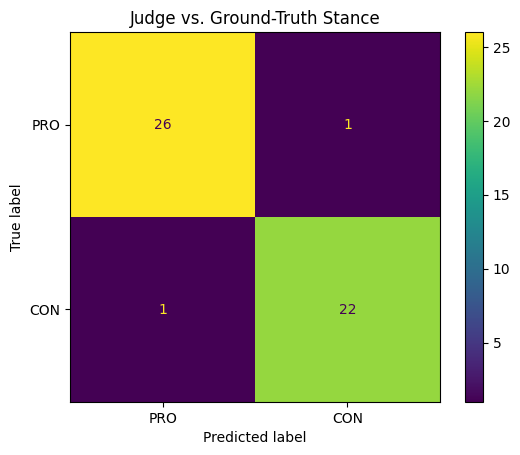

In [58]:
df_res = pd.DataFrame(test_results)

table = pd.crosstab(df_res["stance"], df_res["judge_choice"])
print("\nConfusion Matrix (counts):\n")
print(table)

cm = confusion_matrix(df_res["stance"], df_res["judge_choice"], labels=["PRO", "CON"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["PRO", "CON"])
disp.plot()
plt.title("Judge vs. Ground-Truth Stance")
plt.show()